# Аналіз NBA датасета

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

seasons = pd.read_csv("Seasons_Stats.csv")
players = pd.read_csv("Players.csv")
player_data = pd.read_csv("player_data.csv")

print("Seasons_Stats shape:", seasons.shape)
print("Players shape:", players.shape)
print("player_data shape:", player_data.shape)
seasons.head()

Seasons_Stats shape: (24691, 53)
Players shape: (3922, 8)
player_data shape: (4550, 8)


,Unnamed: 0,Year,Player,Pos,Age,Tm,G,GS,MP,PER,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,0,1950.0,Curly Armstrong,G-F,31.0,FTW,63.0,NaN,NaN,NaN,...,0.705,NaN,NaN,NaN,176.0,NaN,NaN,NaN,217.0,458.0
1,1,1950.0,Cliff Barker,SG,29.0,INO,49.0,NaN,NaN,NaN,...,0.708,NaN,NaN,NaN,109.0,NaN,NaN,NaN,99.0,279.0
2,2,1950.0,Leo Barnhorst,SF,25.0,CHS,67.0,NaN,NaN,NaN,...,0.698,NaN,NaN,NaN,140.0,NaN,NaN,NaN,192.0,438.0
3,3,1950.0,Ed Bartels,F,24.0,TOT,15.0,NaN,NaN,NaN,...,0.559,NaN,NaN,NaN,20.0,NaN,NaN,NaN,29.0,63.0
4,4,1950.0,Ed Bartels,F,24.0,DNN,13.0,NaN,NaN,NaN,...,0.548,NaN,NaN,NaN,20.0,NaN,NaN,NaN,27.0,59.0


## 1. Перший огляд даних
Tипи даних, пропущені значення та основні числові характеристики.

In [7]:
display(seasons.info())
display(seasons.describe())
missing = seasons.isna().sum().sort_values(ascending=False)
missing.head(15)

<class 'pandas.DataFrame'>
RangeIndex: 24691 entries, 0 to 24690
Data columns (total 53 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  24691 non-null  int64  
 1   Year        24624 non-null  float64
 2   Player      24624 non-null  str    
 3   Pos         24624 non-null  str    
 4   Age         24616 non-null  float64
 5   Tm          24624 non-null  str    
 6   G           24624 non-null  float64
 7   GS          18233 non-null  float64
 8   MP          24138 non-null  float64
 9   PER         24101 non-null  float64
 10  TS%         24538 non-null  float64
 11  3PAr        18839 non-null  float64
 12  FTr         24525 non-null  float64
 13  ORB%        20792 non-null  float64
 14  DRB%        20792 non-null  float64
 15  TRB%        21571 non-null  float64
 16  AST%        22555 non-null  float64
 17  STL%        20792 non-null  float64
 18  BLK%        20792 non-null  float64
 19  TOV%        19582 non-null  float64


None

,Unnamed: 0,Year,Age,G,GS,MP,PER,TS%,3PAr,FTr,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
count,24691.000000,24624.000000,24616.000000,24624.000000,18233.000000,24138.000000,24101.000000,24538.000000,18839.000000,24525.000000,...,23766.000000,20797.000000,20797.000000,24312.000000,24624.000000,20797.000000,20797.000000,19645.000000,24624.000000,24624.000000
mean,12345.000000,1992.594989,26.664405,50.837110,23.593375,1209.720317,12.479071,0.493001,0.158604,0.325455,...,0.719279,62.189210,147.199404,224.637381,114.852623,39.897052,24.470260,73.939832,116.339222,510.116350
std,7127.822084,17.429594,3.841892,26.496161,28.632387,941.146575,6.039014,0.094469,0.187495,0.218971,...,0.141824,67.324881,145.921912,228.190203,135.863913,38.713053,36.935084,67.713803,84.791873,492.922981
min,0.000000,1950.000000,18.000000,1.000000,0.000000,0.000000,-90.600000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6172.500000,1981.000000,24.000000,27.000000,0.000000,340.000000,9.800000,0.458000,0.005000,0.208000,...,0.657000,12.000000,33.000000,51.000000,19.000000,9.000000,3.000000,18.000000,39.000000,106.000000
50%,12345.000000,1996.000000,26.000000,58.000000,8.000000,1053.000000,12.700000,0.506000,0.064000,0.296000,...,0.743000,38.000000,106.000000,159.000000,68.000000,29.000000,11.000000,55.000000,109.000000,364.000000
75%,18517.500000,2007.000000,29.000000,75.000000,45.000000,1971.000000,15.600000,0.544000,0.288000,0.400000,...,0.808000,91.000000,212.000000,322.000000,160.000000,60.000000,29.000000,112.000000,182.000000,778.000000
max,24690.000000,2017.000000,44.000000,88.000000,83.000000,3882.000000,129.100000,1.136000,1.000000,6.000000,...,1.000000,587.000000,1111.000000,2149.000000,1164.000000,301.000000,456.000000,464.000000,386.000000,4029.000000


blank2    24691
blanl     24691
3P%        9275
GS         6458
3PAr       5852
3PA        5764
3P         5764
TOV%       5109
USG%       5051
TOV        5046
STL%       3899
ORB%       3899
DRB%       3899
BLK%       3899
STL        3894
dtype: int64

## 2. Очищення даних

In [9]:
df = seasons.copy()
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df = df.dropna(subset=["Year", "Player"])
df["Year"] = df["Year"].astype(int)

fill_zero_cols = ["3P", "3PA", "ORB", "DRB", "TRB", "AST", "STL", "BLK", "TOV", "PTS", "MP", "G", "FG", "FGA", "FT", "FTA"]
for col in fill_zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)
print(df.shape)
df.head()

(24624, 52)


,Year,Player,Pos,Age,Tm,G,GS,MP,PER,TS%,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,1950,Curly Armstrong,G-F,31.0,FTW,63.0,NaN,0.0,NaN,0.368,...,0.705,0.0,0.0,0.0,176.0,0.0,0.0,0.0,217.0,458.0
1,1950,Cliff Barker,SG,29.0,INO,49.0,NaN,0.0,NaN,0.435,...,0.708,0.0,0.0,0.0,109.0,0.0,0.0,0.0,99.0,279.0
2,1950,Leo Barnhorst,SF,25.0,CHS,67.0,NaN,0.0,NaN,0.394,...,0.698,0.0,0.0,0.0,140.0,0.0,0.0,0.0,192.0,438.0
3,1950,Ed Bartels,F,24.0,TOT,15.0,NaN,0.0,NaN,0.312,...,0.559,0.0,0.0,0.0,20.0,0.0,0.0,0.0,29.0,63.0
4,1950,Ed Bartels,F,24.0,DNN,13.0,NaN,0.0,NaN,0.308,...,0.548,0.0,0.0,0.0,20.0,0.0,0.0,0.0,27.0,59.0


## 3. Створення нових фічей


In [10]:
df["points_per_game"] = np.where(df["G"] > 0, df["PTS"] / df["G"], np.nan)
df["rebounds_per_game"] = np.where(df["G"] > 0, df["TRB"] / df["G"], np.nan)
df["assists_per_game"] = np.where(df["G"] > 0, df["AST"] / df["G"], np.nan)
df["minutes_per_game"] = np.where(df["G"] > 0, df["MP"] / df["G"], np.nan)
df["three_point_share"] = np.where(df["FGA"] > 0, df["3PA"] / df["FGA"], np.nan)
df["free_throw_rate_manual"] = np.where(df["FGA"] > 0, df["FTA"] / df["FGA"], np.nan)
df["scoring_efficiency"] = np.where(df["FGA"] > 0, df["PTS"] / df["FGA"], np.nan)
df["total_contribution"] = df["PTS"] + df["TRB"] + df["AST"] + df["STL"] + df["BLK"]
df["is_modern_era"] = df["Year"] >= 1980

new_features = [
    "points_per_game", "rebounds_per_game", "assists_per_game", "minutes_per_game",
    "three_point_share", "free_throw_rate_manual", "scoring_efficiency",
    "total_contribution", "is_modern_era"
]

df[["Year", "Player", "Pos", "PTS", "G"] + new_features].head()

,Year,Player,Pos,PTS,G,points_per_game,rebounds_per_game,assists_per_game,minutes_per_game,three_point_share,free_throw_rate_manual,scoring_efficiency,total_contribution,is_modern_era
0,1950,Curly Armstrong,G-F,458.0,63.0,7.269841,0.0,2.793651,0.0,0.0,0.467054,0.887597,634.0,False
1,1950,Cliff Barker,SG,279.0,49.0,5.693878,0.0,2.224490,0.0,0.0,0.386861,1.018248,388.0,False
2,1950,Leo Barnhorst,SF,438.0,67.0,6.537313,0.0,2.089552,0.0,0.0,0.258517,0.877756,578.0,False
3,1950,Ed Bartels,F,63.0,15.0,4.200000,0.0,1.333333,0.0,0.0,0.395349,0.732558,83.0,False
4,1950,Ed Bartels,F,59.0,13.0,4.538462,0.0,1.538462,0.0,0.0,0.378049,0.719512,79.0,False


**Нові фічі:**
1. `points_per_game` очки за гру.
2. `rebounds_per_game` підбирання за гру.
3. `assists_per_game` передачі за гру.
4. `minutes_per_game` хвилини за гру.
5. `three_point_share` частка триочкових спроб серед усіх кидків.
6. `free_throw_rate_manual` відношення штрафних спроб до кидків з гри.
7. `scoring_efficiency` скільки очок гравець набирає на одну спробу кидка.
8. `total_contribution` загальна умовна користь: очки + підбирання + передачі + перехоплення + блоки.
9. `is_modern_era` чи сезон після 1980 року.

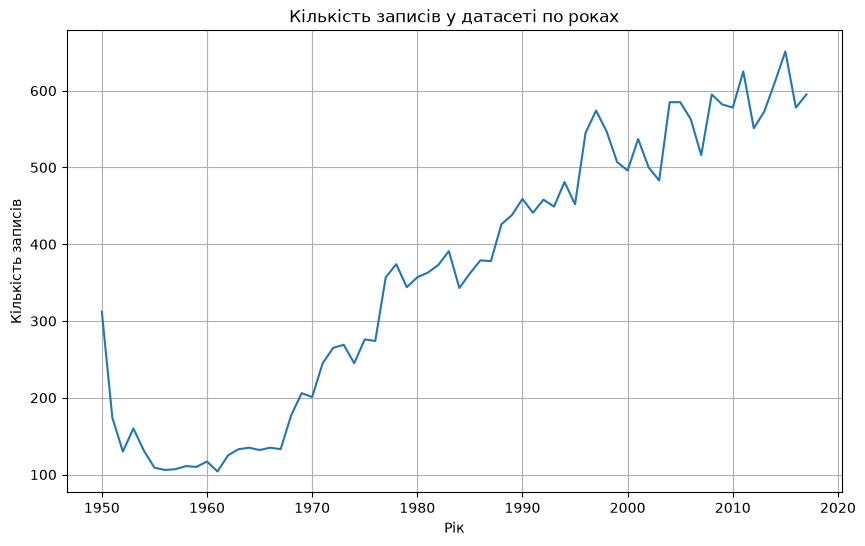

In [11]:
yearly_count = df.groupby("Year").size()
plt.figure()
yearly_count.plot(kind="line")
plt.title("Кількість записів у датасеті по роках")
plt.xlabel("Рік")
plt.ylabel("Кількість записів")
plt.show()

**Резюме 1:** Кількість записів з часом зростає. NBA розширювалася: ставало більше команд, гравців і статистики.

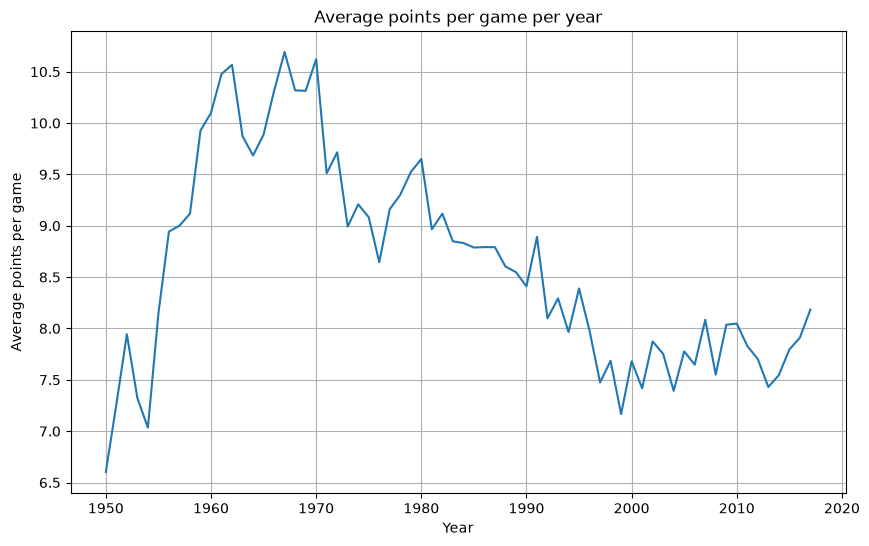

In [14]:
yearly_ppg = df.groupby("Year")["points_per_game"].mean()
plt.figure()
yearly_ppg.plot(kind="line")
plt.title("Average points per game per year")
plt.xlabel("Year")
plt.ylabel("Average points per game")
plt.show()

**Резюме 2:** Середня результативність змінювалася залежно від епохи. У сучасні роки темп гри та роль триочкових кидків впливають на набір очок.

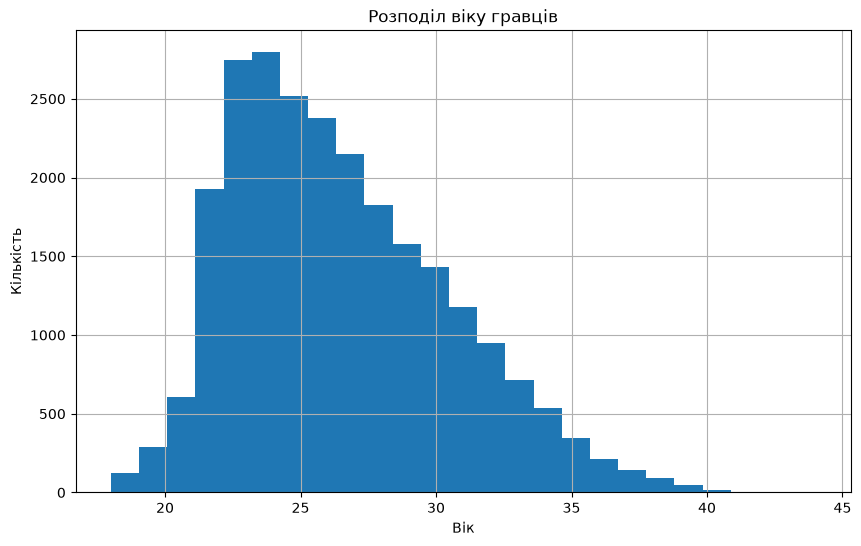

In [15]:
plt.figure()
df["Age"].dropna().plot(kind="hist", bins=25)
plt.title("Розподіл віку гравців")
plt.xlabel("Вік")
plt.ylabel("Кількість")
plt.show()

**Резюме 3:** Найбільше сезонів припадає на гравців приблизно 23–30 років. Після 35 років кількість гравців значно менша.

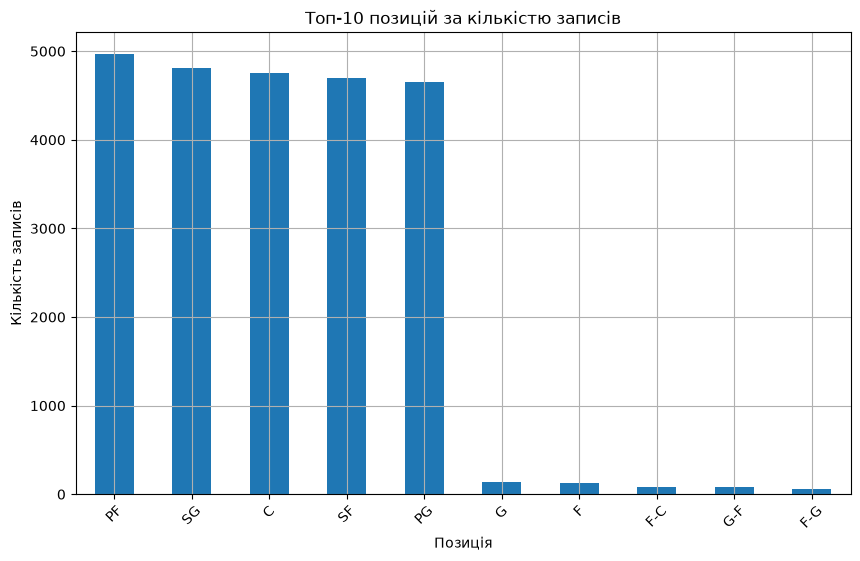

In [16]:
pos_counts = df["Pos"].value_counts().head(10)
plt.figure()
pos_counts.plot(kind="bar")
plt.title("Топ-10 позицій за кількістю записів")
plt.xlabel("Позиція")
plt.ylabel("Кількість записів")
plt.xticks(rotation=45)
plt.show()

**Резюме 4:** Найчастіше зустрічаються класичні позиції на кшталт SG, PF, C, PG, SF. Комбіновані позиції теж є, але їх менше.

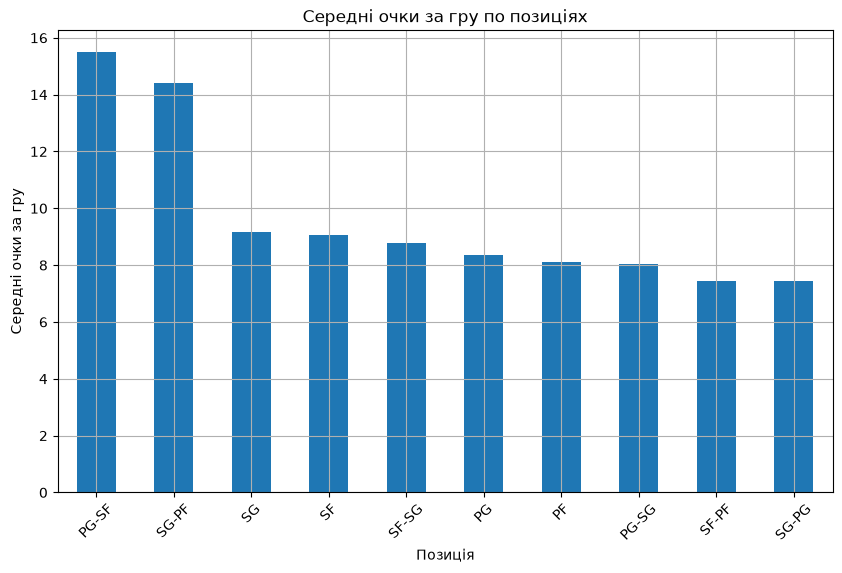

In [17]:
pos_ppg = df.groupby("Pos")["points_per_game"].mean().sort_values(ascending=False).head(10)
plt.figure()
pos_ppg.plot(kind="bar")
plt.title("Середні очки за гру по позиціях")
plt.xlabel("Позиція")
plt.ylabel("Середні очки за гру")
plt.xticks(rotation=45)
plt.show()

**Резюме 5:** Деякі позиції мають вищу середню результативність, бо їхня роль частіше пов’язана з атакою та кидками.

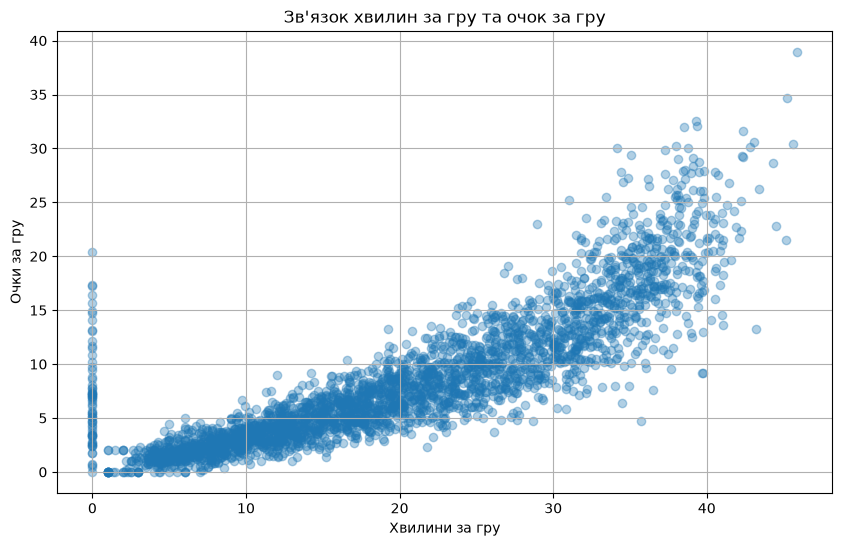

In [18]:
sample = df.dropna(subset=["points_per_game", "minutes_per_game"]).sample(min(3000, len(df)), random_state=42)
plt.figure()
plt.scatter(sample["minutes_per_game"], sample["points_per_game"], alpha=0.35)
plt.title("Зв'язок хвилин за гру та очок за гру")
plt.xlabel("Хвилини за гру")
plt.ylabel("Очки за гру")
plt.show()

**Резюме 6:** Видно позитивний зв’язок: гравці, які проводять більше хвилин на майданчику, зазвичай набирають більше очок.

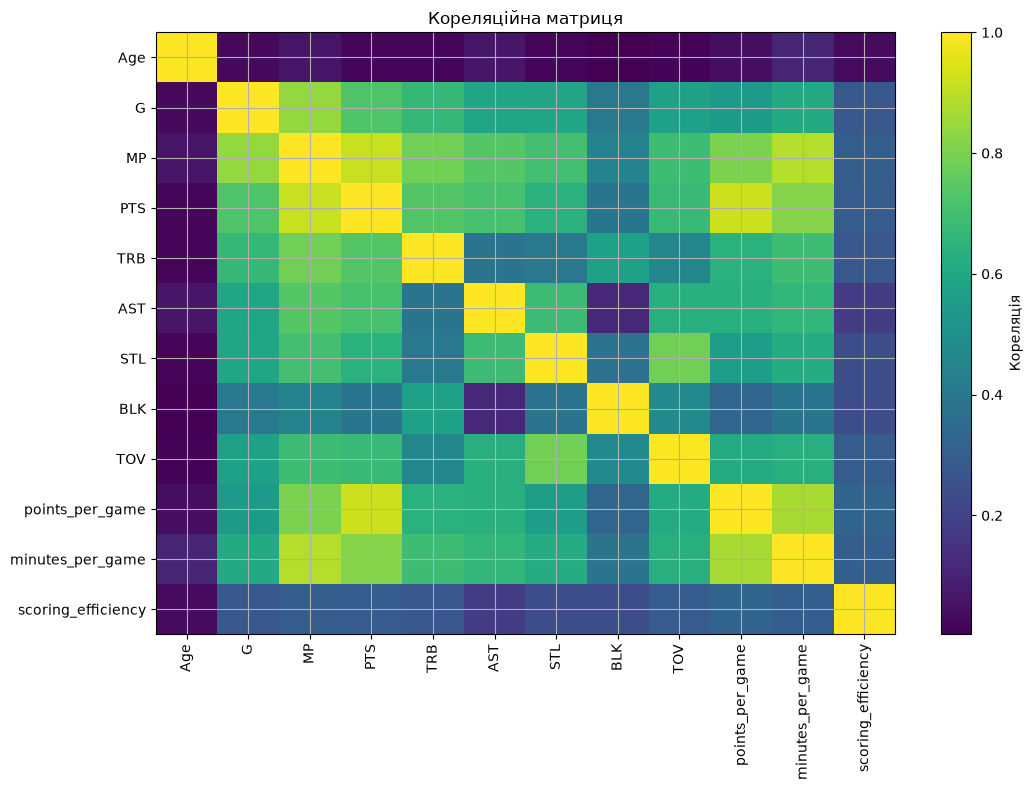

In [19]:
cols = ["Age", "G", "MP", "PTS", "TRB", "AST", "STL", "BLK", "TOV", "points_per_game", "minutes_per_game", "scoring_efficiency"]
corr = df[cols].corr(numeric_only=True)
plt.figure(figsize=(11, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Кореляція")
plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks(range(len(cols)), cols)
plt.title("Кореляційна матриця")
plt.tight_layout()
plt.show()

**Резюме 7:** Очки, хвилини, передачі та підбирання часто мають помітний зв’язок, бо активніші гравці отримують більше ігрового часу та більше статистичних дій.

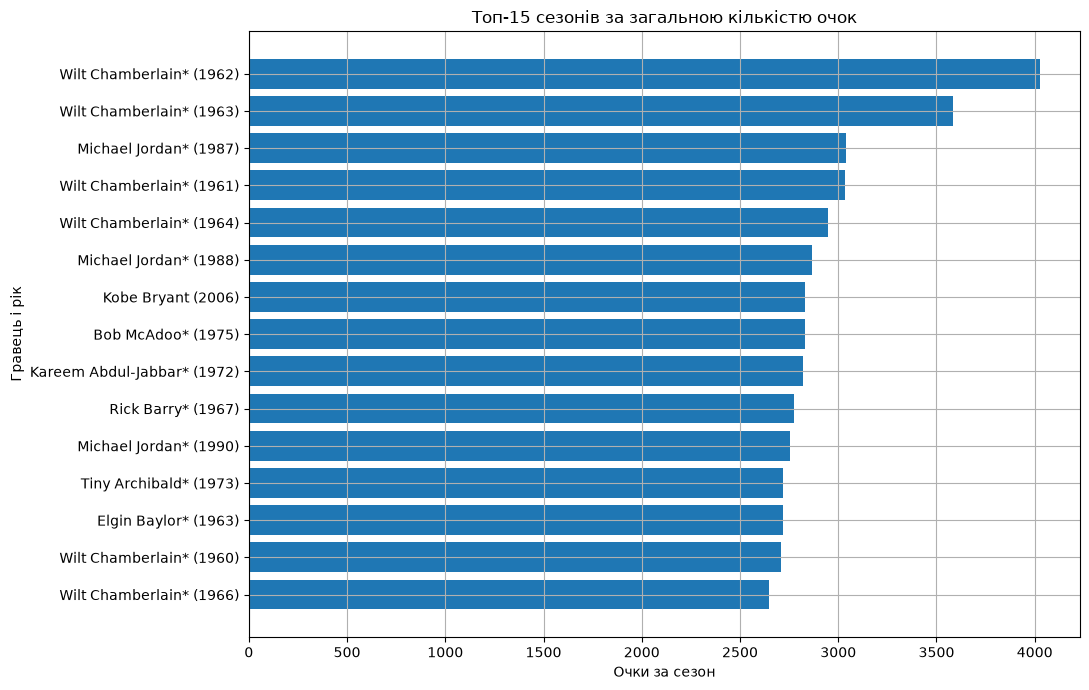

In [20]:
top_pts = df.sort_values("PTS", ascending=False).head(15)
plt.figure(figsize=(11, 7))
plt.barh(top_pts["Player"] + " (" + top_pts["Year"].astype(str) + ")", top_pts["PTS"])
plt.gca().invert_yaxis()
plt.title("Топ-15 сезонів за загальною кількістю очок")
plt.xlabel("Очки за сезон")
plt.ylabel("Гравець і рік")
plt.tight_layout()
plt.show()

**Резюме 8:** Найрезультативніші сезони мають дуже великі значення очок. Це показує, що окремі суперзірки сильно виділяються на фоні середнього гравця.

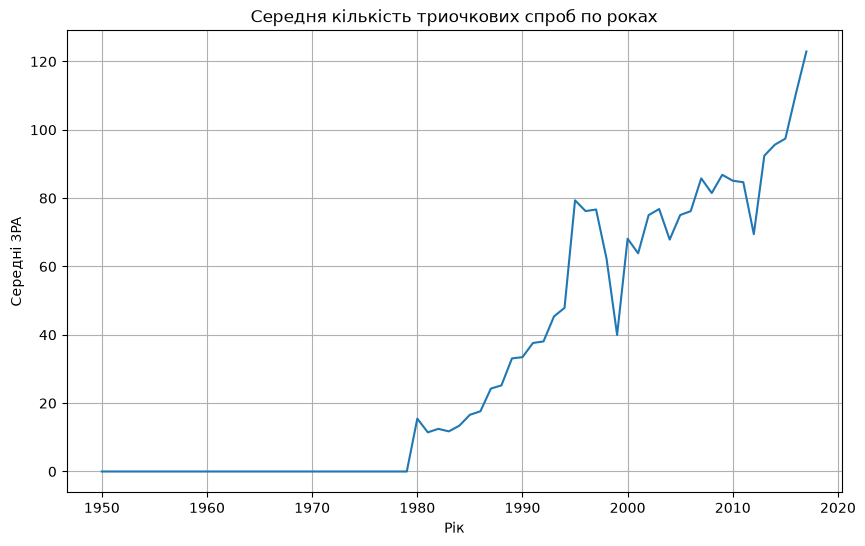

In [21]:
yearly_3pa = df.groupby("Year")["3PA"].mean()
plt.figure()
yearly_3pa.plot(kind="line")
plt.title("Середня кількість триочкових спроб по роках")
plt.xlabel("Рік")
plt.ylabel("Середні 3PA")
plt.show()

**Резюме 9:** Після появи триочкової лінії кількість триочкових спроб поступово зростає.

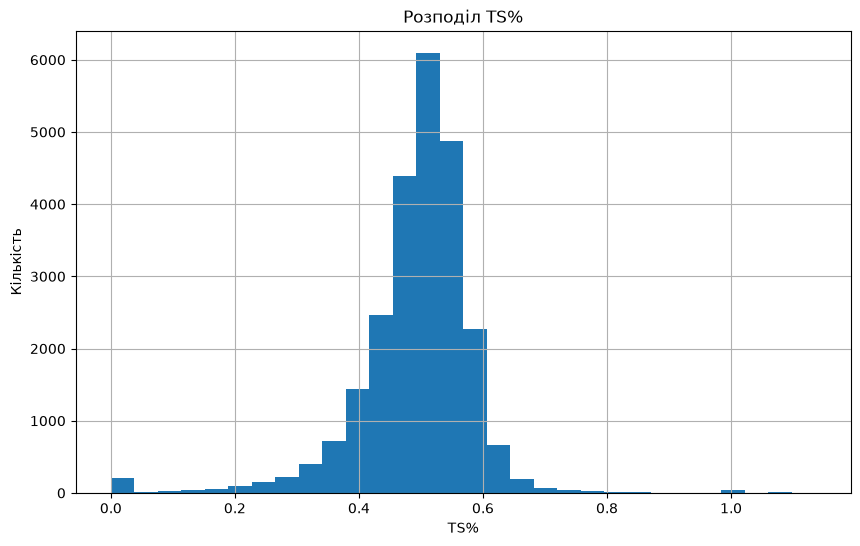

In [22]:
plt.figure()
df["TS%"].dropna().plot(kind="hist", bins=30)
plt.title("Розподіл TS%")
plt.xlabel("TS%")
plt.ylabel("Кількість")
plt.show()

**Резюме 10:** Більшість значень TS% сконцентрована в середньому діапазоні. Дуже низькі або дуже високі значення зустрічаються рідше.

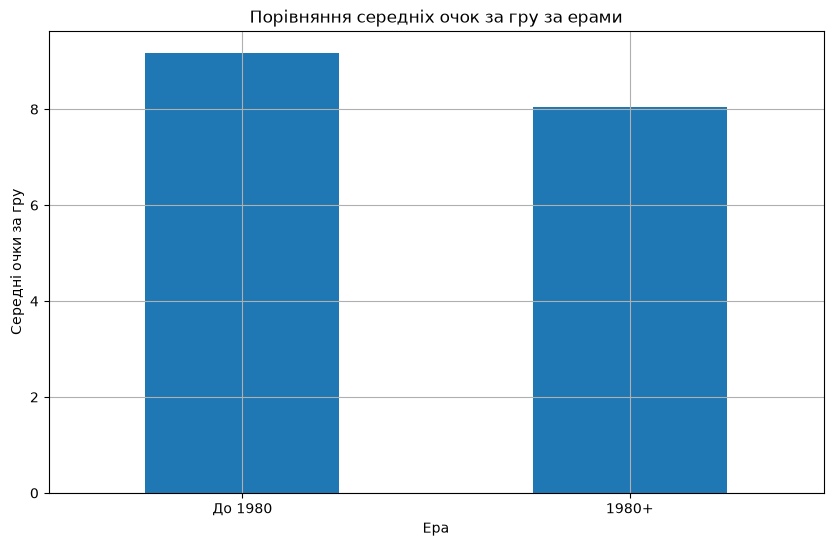

In [23]:
era_ppg = df.groupby("is_modern_era")["points_per_game"].mean()
era_ppg.index = ["До 1980", "1980+"]
plt.figure()
era_ppg.plot(kind="bar")
plt.title("Порівняння середніх очок за гру за ерами")
plt.xlabel("Ера")
plt.ylabel("Середні очки за гру")
plt.xticks(rotation=0)
plt.show()

**Резюме 11:** Порівняння епох допомагає побачити, як стиль гри змінювався з часом. Сучасна ера має інші правила, темп і більшу роль дальніх кидків.

<Figure size 1000x600 with 0 Axes>

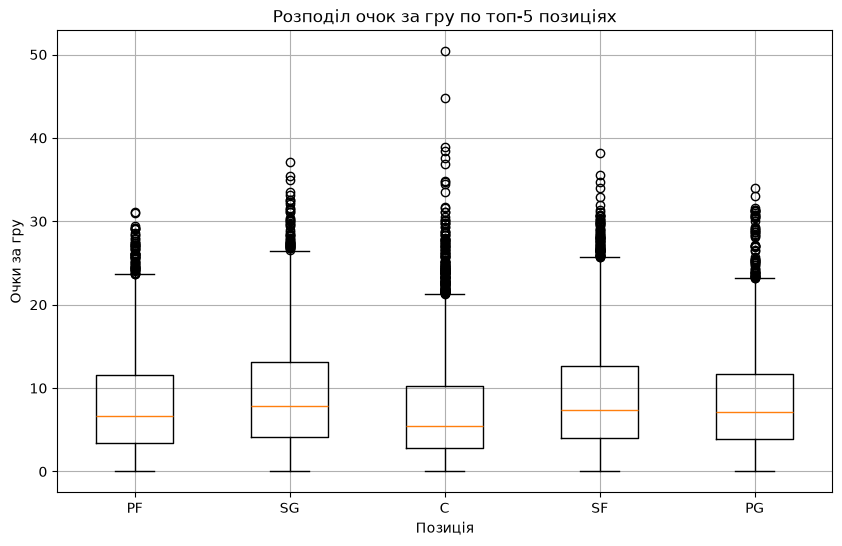

In [25]:
top_positions = df["Pos"].value_counts().head(5).index
box_data = [df.loc[df["Pos"] == pos, "points_per_game"].dropna() for pos in top_positions]
plt.figure()
plt.figure()
plt.boxplot(box_data)
plt.xticks(range(1, len(top_positions) + 1), top_positions)
plt.title("Розподіл очок за гру по топ-5 позиціях")
plt.xlabel("Позиція")
plt.ylabel("Очки за гру")
plt.show()

**Резюме 12:** Boxplot показує не тільки середні значення, а й розкид. На кожній позиції є як рольові гравці з невеликою результативністю, так і сильні.

## 4. Автоматична генерація нових фічей
Для додаткового завдання використаємо бібліотеку `sklearn` і клас `PolynomialFeatures`. Він автоматично створює нові фічі на основі взаємодій між числовими колонками: квадрати, добутки між колонками тощо.

In [26]:
auto_base = df[["Age", "G", "MP", "PTS", "TRB", "AST"]].dropna().copy()

poly = PolynomialFeatures(degree=2, include_bias=False)
auto_features_array = poly.fit_transform(auto_base)
auto_feature_names = poly.get_feature_names_out(auto_base.columns)

auto_features = pd.DataFrame(auto_features_array, columns=auto_feature_names, index=auto_base.index)

print("Було фічей:", auto_base.shape[1])
print("Стало фічей після автоматичної генерації:", auto_features.shape[1])
print("Перші автоматично створені фічі:")
display(auto_features.head())
print(list(auto_feature_names))

Було фічей: 6
Стало фічей після автоматичної генерації: 27
Перші автоматично створені фічі:


,Age,G,MP,PTS,TRB,AST,Age^2,Age G,Age MP,Age PTS,...,MP^2,MP PTS,MP TRB,MP AST,PTS^2,PTS TRB,PTS AST,TRB^2,TRB AST,AST^2
0,31.0,63.0,0.0,458.0,0.0,176.0,961.0,1953.0,0.0,14198.0,...,0.0,0.0,0.0,0.0,209764.0,0.0,80608.0,0.0,0.0,30976.0
1,29.0,49.0,0.0,279.0,0.0,109.0,841.0,1421.0,0.0,8091.0,...,0.0,0.0,0.0,0.0,77841.0,0.0,30411.0,0.0,0.0,11881.0
2,25.0,67.0,0.0,438.0,0.0,140.0,625.0,1675.0,0.0,10950.0,...,0.0,0.0,0.0,0.0,191844.0,0.0,61320.0,0.0,0.0,19600.0
3,24.0,15.0,0.0,63.0,0.0,20.0,576.0,360.0,0.0,1512.0,...,0.0,0.0,0.0,0.0,3969.0,0.0,1260.0,0.0,0.0,400.0
4,24.0,13.0,0.0,59.0,0.0,20.0,576.0,312.0,0.0,1416.0,...,0.0,0.0,0.0,0.0,3481.0,0.0,1180.0,0.0,0.0,400.0


['Age', 'G', 'MP', 'PTS', 'TRB', 'AST', 'Age^2', 'Age G', 'Age MP', 'Age PTS', 'Age TRB', 'Age AST', 'G^2', 'G MP', 'G PTS', 'G TRB', 'G AST', 'MP^2', 'MP PTS', 'MP TRB', 'MP AST', 'PTS^2', 'PTS TRB', 'PTS AST', 'TRB^2', 'TRB AST', 'AST^2']


**Автоматична генерація:**
`PolynomialFeatures` створила нові ознаки автоматично. Наприклад, `Age^2`, `Age G`, `MP PTS`, `TRB AST` тощо.

## 5. Загальний висновок
Датасет містить сезонну статистику NBA за багато років. Після аналізу видно, що кількість записів збільшується з часом, стиль гри змінюється, а триочкові кидки стали значно важливішими в сучасній ері. Найбільше на результативність впливають хвилини на майданчику, роль гравця та його позиція. Нові фічі, створені вручну й автоматично, можуть бути використані для подальшого аналізу або побудови ML-моделей.